In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.makedirs('/content/drive/MyDrive/resnet_project', exist_ok=True)

Mounted at /content/drive


In [ ]:
from google.colab import files # For downloading the model weights locally from colab instance

In [3]:
import sys
import os
import torch
import torch.nn as nn
from datasets import load_dataset
from torchvision import transforms as T
from torch.utils.data import DataLoader, Dataset
from models import ResNet_12
from models import ResNet_18
from models import ResNet_34
from models import ResNet_50

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda


In [10]:
batch_size=64

In [ ]:
# Using the CIFAR100 dataset since it gets the best out of both worlds (relatively small + relatively difficult task for ResNet) for our from-scratch ResNet models
dataset = load_dataset("uoft-cs/cifar100")

README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  119MB            

cifar100/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cifar100/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.8MB            

cifar100/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
cifar_100_labels = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

In [ ]:
"""Class for applying the desired transforms on CIFAR-100 for train/val splits"""
class CIFAR100(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        img = item['img']
        label = item['fine_label']

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
transforms_r12_train = T.Compose([
    T.Grayscale(num_output_channels=1), # Transform in mono-channel for R12 which accepts num_channels=1
    T.Resize((9, 110)), # Scaled up template
    T.RandomCrop((7, 96)), # Fits the asymmetry
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

transforms_r12_test = T.Compose([
    T.Grayscale(num_output_channels=1), # Transform in mono-channel for R12 which accepts num_channels=1
    T.Resize((7, 96)), # Fits the asymmetry
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

transforms_r18_train = T.Compose([
    T.Resize((112, 112)), # Scaled up template
    T.RandomCrop((100, 100)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]), # ImageNet normalization standards
])

transforms_r18_test = T.Compose([
    T.Resize((100, 100)),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]), # ImageNet normalization standards
])

transforms_r34_train = T.Compose([
    T.Resize((256, 256)), # Scaled up template
    T.RandomCrop((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
])

transforms_r34_test = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
])

transforms_r50_train = T.Compose([
    T.Resize((256, 256)), # Scaled up template
    T.RandomCrop((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

transforms_r50_test = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

In [ ]:
"""Dataset initialization"""
train_r12 = CIFAR100(dataset['train'], transform=transforms_r12_train)
val_r12 = CIFAR100(dataset['test'], transform=transforms_r12_test)

train_r18 = CIFAR100(dataset['train'], transform=transforms_r18_train)
val_r18 = CIFAR100(dataset['test'], transform=transforms_r18_test)

train_r34 = CIFAR100(dataset['train'], transform=transforms_r34_train)
val_r34 = CIFAR100(dataset['test'], transform=transforms_r34_test)

train_r50 = CIFAR100(dataset['train'], transform=transforms_r50_train)
val_r50 = CIFAR100(dataset['test'], transform=transforms_r50_test)

In [ ]:
"""Dataloaders initialization"""
loader_train_r12 = DataLoader(train_r12, batch_size=batch_size, shuffle=True)
loader_val_r12 = DataLoader(val_r12, batch_size=batch_size, shuffle=False)

loader_train_r18 = DataLoader(train_r18, batch_size=batch_size, shuffle=True)
loader_val_r18 = DataLoader(val_r18, batch_size=batch_size, shuffle=False)

loader_train_r34 = DataLoader(train_r34, batch_size=batch_size, shuffle=True)
loader_val_r34 = DataLoader(val_r34, batch_size=batch_size, shuffle=False)

loader_train_r50 = DataLoader(train_r50, batch_size=batch_size, shuffle=True)
loader_val_r50 = DataLoader(val_r50, batch_size=batch_size, shuffle=False)

## Custom built transforms effect on random CIFAR-100 extracted images

Image shape: torch.Size([1, 7, 96])
Label: 14 <--> butterfly


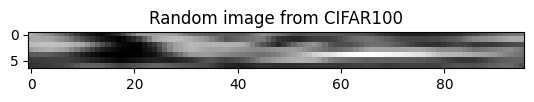

In [ ]:
"""Visualizing the desired transformations applied on the CIFAR100 dataset for our ResNet_12-from-scratch model"""
import random
import matplotlib.pyplot as plt

imager12, labelr12 = next(iter(loader_train_r12))

batch_size = imager12.shape[0]
rand_idx = random.randint(0, batch_size - 1)  # 128 is vanilla batch_size for our ResNets-from-scratch
print(f"Image shape: {imager12[rand_idx].shape}")
print(f"Label: {labelr12[rand_idx].item()} <--> {cifar_100_labels[labelr12[rand_idx].item()]}")

# PyTorch color order -> [C, H, W] (In our case [1, 8, 32])
# Matplotlib color order -> [H, W, C] ([32, 8, 1])
# Solution: .squeeze(0)

plt.imshow(imager12[rand_idx].squeeze(0), cmap='gray')
plt.title("Random image from CIFAR100")
plt.show()

Image shape: torch.Size([3, 100, 100])
Label: 95 <--> table


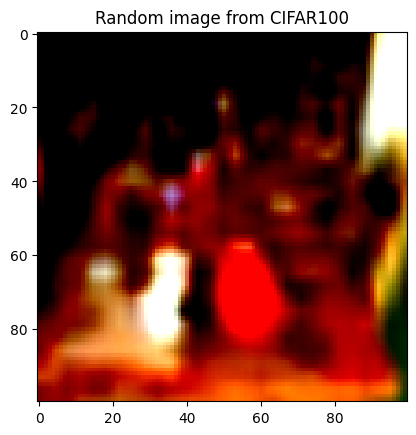

In [ ]:
"""Visualizing the desired transformations applied on the CIFAR100 dataset for our ResNet_18-from-scratch model"""
import random
import matplotlib.pyplot as plt

imager18, labelr18 = next(iter(loader_train_r18))

batch_size = imager18.shape[0]
rand_idx = random.randint(0, batch_size - 1)  # 128 is vanilla batch_size for our ResNets-from-scratch
print(f"Image shape: {imager18[rand_idx].shape}")
print(f"Label: {labelr12[rand_idx].item()} <--> {cifar_100_labels[labelr18[rand_idx].item()]}")

# PyTorch color order -> [C, H, W] (In our case [3, 100, 100])
# Matplotlib color order -> [H, W, C] ([100, 100, 3])
# Solution: .permute(1, 2, 0)

plt.imshow(imager18[rand_idx].permute(1, 2, 0))
plt.title("Random image from CIFAR100")
plt.show()

Image shape: torch.Size([3, 224, 224])
Label: 45 <--> lobster


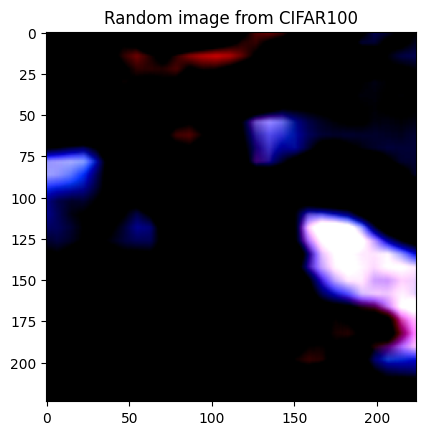

In [ ]:
"""Visualizing the desired transformations applied on the CIFAR100 dataset for our ResNet_34-from-scratch model"""
import random
import matplotlib.pyplot as plt

imager34, labelr34 = next(iter(loader_train_r34))

batch_size = imager34.shape[0]
rand_idx = random.randint(0, batch_size - 1)  # 128 is vanilla batch_size for our ResNets-from-scratch
print(f"Image shape: {imager34[rand_idx].shape}")
print(f"Label: {labelr34[rand_idx].item()} <--> {cifar_100_labels[labelr34[rand_idx].item()]}")

# PyTorch color order -> [C, H, W] (In our case [3, 224, 224])
# Matplotlib color order -> [H, W, C] ([224, 224, 3])
# Solution: .permute(1, 2, 0)

plt.imshow(imager34[rand_idx].permute(1, 2, 0))
plt.title("Random image from CIFAR100")
plt.show()

In [6]:
"""Models initialization"""
resnet12 = ResNet_12(in_channels=1, num_classes=100).to(device)
resnet18 = ResNet_18(in_channels=3, num_classes=100).to(device)
resnet34 = ResNet_34(in_channels=3, num_classes=100).to(device)
resnet50 = ResNet_50(in_channels=3, num_classes=100).to(device)

In [11]:
print(f"""The parameter count of all ResNets-from-scratch are:
- ResNet_12 -> {resnet12.params()} (~ {resnet12.params()//1000}K)
- ResNet_18 -> {resnet18.params()} (~ 11.2M)
- ResNet_34 -> {resnet34.params()} (~ 21.3M)
- ResNet_50 -> {resnet50.params()} (~ 23.7M)
""")

The parameter count of all ResNets-from-scratch are:
- ResNet_12 -> 377124 (~ 377K)
- ResNet_18 -> 11227812 (~ 11.2M)
- ResNet_34 -> 21335972 (~ 21.3M)
- ResNet_50 -> 23712932 (~ 23.7M)



In [ ]:
"""ResNet_12-from-scratch training class method"""
train_loss_hist_r12, val_loss_hist_r12, y_true_hist_r12, y_pred_hist_r12 = resnet12.fit(train_loader=loader_train_r12, val_loader=loader_val_r12, track=True, device=device)

ResNet_12 training will start on: CUDA
Epoch: 1 | Batch: 000 | Batch Loss 5.0147
Epoch: 1 | Batch: 100 | Batch Loss 4.3277
Epoch: 1 | Batch: 200 | Batch Loss 4.2317
Epoch: 1 | Batch: 300 | Batch Loss 4.3060
Epoch 01/30 completed | Train Loss: 4.3343 | Val Loss: 4.1329 | Val Acc: 7.52%
Epoch: 2 | Batch: 000 | Batch Loss 4.0451
Epoch: 2 | Batch: 100 | Batch Loss 4.0206
Epoch: 2 | Batch: 200 | Batch Loss 4.1403
Epoch: 2 | Batch: 300 | Batch Loss 3.8782
Epoch 02/30 completed | Train Loss: 4.0290 | Val Loss: 3.9575 | Val Acc: 10.61%
Epoch: 3 | Batch: 000 | Batch Loss 3.9438
Epoch: 3 | Batch: 100 | Batch Loss 3.9819
Epoch: 3 | Batch: 200 | Batch Loss 3.8735
Epoch: 3 | Batch: 300 | Batch Loss 3.7616
Epoch 03/30 completed | Train Loss: 3.8490 | Val Loss: 4.0026 | Val Acc: 10.15%
Epoch: 4 | Batch: 000 | Batch Loss 3.7120
Epoch: 4 | Batch: 100 | Batch Loss 3.7940
Epoch: 4 | Batch: 200 | Batch Loss 3.6523
Epoch: 4 | Batch: 300 | Batch Loss 3.8182
Epoch 04/30 completed | Train Loss: 3.7284 | Val L

In [ ]:
resnet12.save()

ResNet_12 model saved to /content/drive/MyDrive/resnet_project/ResNet_Family-from-scratch/ResNet12_model.pth


In [ ]:
files.download('ResNet12_model.pth')

In [ ]:
"""Mostly boilerplate/boring matplotlib code"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss_hist_r12, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during ResNet-12 Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 30): # 30 is the number of epochs we trained the "ResNet_12-from-scratch in Pytorch" model for
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss_hist_r12[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(val_loss_hist_r12, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during ResNet-12 Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 30):
    ax2.annotate(f'Epoch {i}', xy=(i-1, val_loss_hist_r12[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()

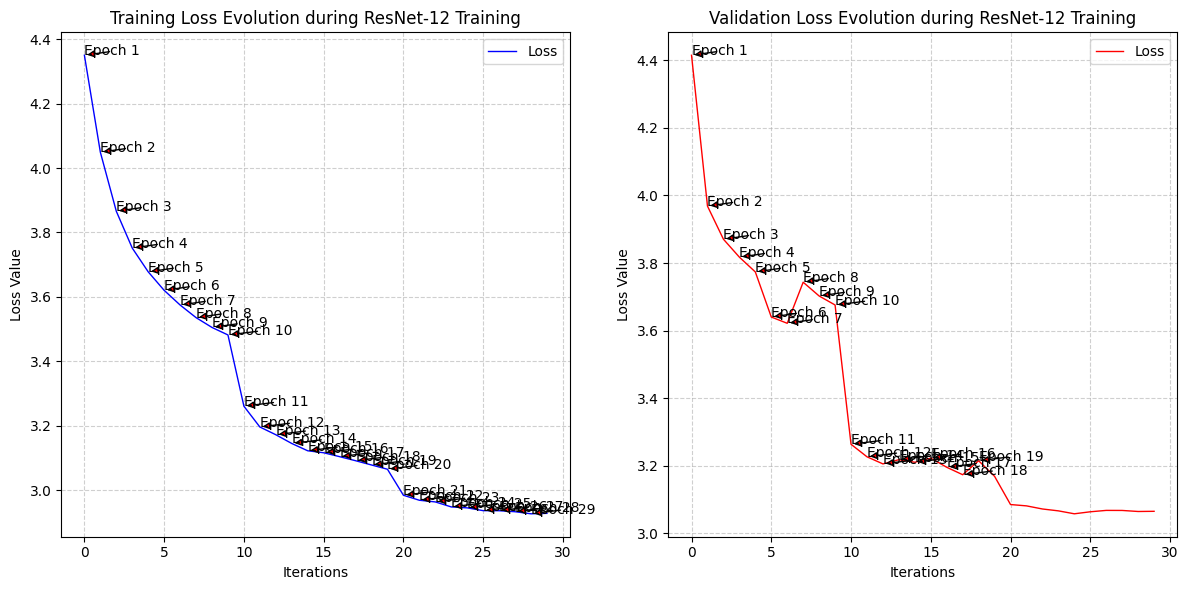

In [ ]:
"""ResNet_18-from-scratch training class method"""
train_loss_hist_r18_u, val_loss_hist_r18_u, y_true_hist_r18_u, y_pred_hist_r18_u = resnet18.fit(train_loader=loader_train_r18, val_loader=loader_val_r18, track=True, device=device, epochs=3)

ResNet_18 training will start on: CUDA
Mixed precision: ENABLED
Epoch: 1 | Lr: 0.05 | Batch: 000 | Batch Loss 2.6618
Epoch: 1 | Lr: 0.05 | Batch: 100 | Batch Loss 1.8708
Epoch: 1 | Lr: 0.05 | Batch: 200 | Batch Loss 1.9719
Epoch: 1 | Lr: 0.05 | Batch: 300 | Batch Loss 1.8100
Epoch: 1 | Lr: 0.05 | Batch: 400 | Batch Loss 1.6586
Epoch: 1 | Lr: 0.05 | Batch: 500 | Batch Loss 2.0287
Epoch: 1 | Lr: 0.05 | Batch: 600 | Batch Loss 2.4419
Epoch: 1 | Lr: 0.05 | Batch: 700 | Batch Loss 1.8596
Epoch 01/03 completed | Train Loss: 2.0485 | Val Loss: 2.0524 | Val Acc: 44.67%
Epoch: 2 | Lr: 0.005000000000000001 | Batch: 000 | Batch Loss 1.8503
Epoch: 2 | Lr: 0.005000000000000001 | Batch: 100 | Batch Loss 1.3400
Epoch: 2 | Lr: 0.005000000000000001 | Batch: 200 | Batch Loss 1.1708
Epoch: 2 | Lr: 0.005000000000000001 | Batch: 300 | Batch Loss 1.4805


In [ ]:
resnet18.save()

ResNet_18 model saved to ResNet18_model.pth


In [ ]:
files.download('ResNet18_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

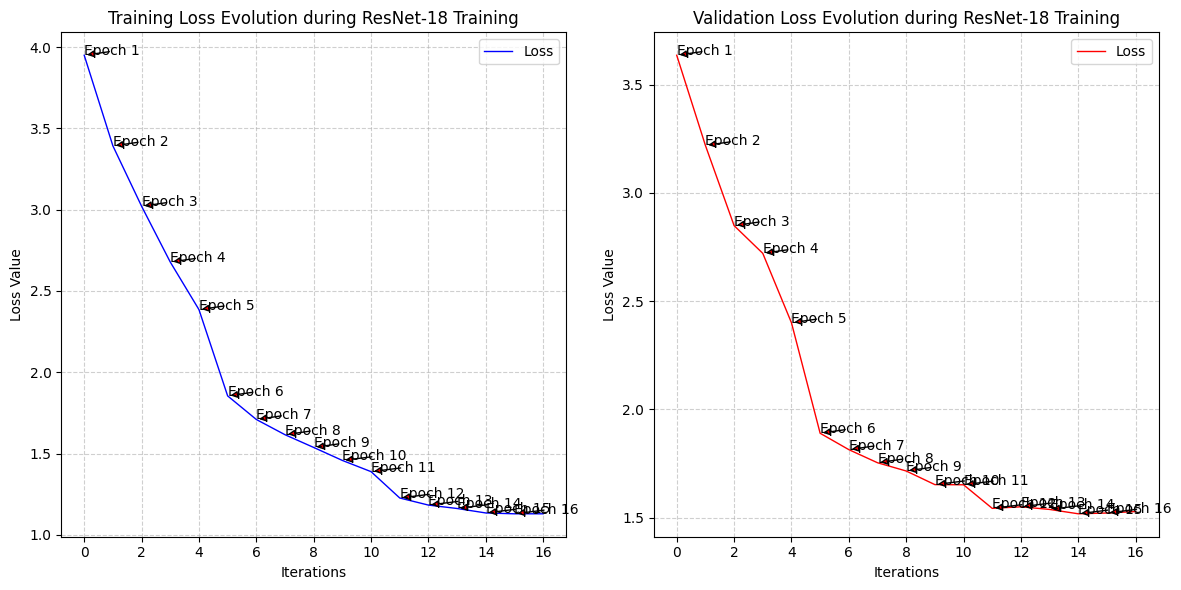

In [ ]:
import matplotlib.pyplot as plt

"""Mostly boilerplate/boring matplotlib code"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss_hist_r18, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during ResNet-18 Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 17): # 17 is the number of epochs we trained the "ResNet_18-from-scratch in Pytorch" model for (due to Colab Limits mainly)
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss_hist_r18[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(val_loss_hist_r18, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during ResNet-18 Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 17):
    ax2.annotate(f'Epoch {i}', xy=(i-1, val_loss_hist_r18[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
"""ResNet_34-from-scratch training class method"""
train_loss_hist_r34, val_loss_hist_r34, y_true_hist_r34, y_pred_hist_r34 = resnet34.fit(train_loader=loader_train_r34, val_loader=loader_val_r34, device=device, track=True, epochs=20)

ResNet_34 training will start on: CUDA
Mixed precision: ENABLED
Epoch: 1 | Lr: 0.05 | Batch: 000 | Batch Loss 4.8273
Epoch: 1 | Lr: 0.05 | Batch: 100 | Batch Loss 4.3812
Epoch: 1 | Lr: 0.05 | Batch: 200 | Batch Loss 4.1486
Epoch: 1 | Lr: 0.05 | Batch: 300 | Batch Loss 3.9783
Epoch: 1 | Lr: 0.05 | Batch: 400 | Batch Loss 3.8566
Epoch: 1 | Lr: 0.05 | Batch: 500 | Batch Loss 3.9745
Epoch: 1 | Lr: 0.05 | Batch: 600 | Batch Loss 3.6401
Epoch: 1 | Lr: 0.05 | Batch: 700 | Batch Loss 3.9110
Epoch 01/20 completed | Train Loss: 4.0533 | Val Loss: 3.8519 | Val Acc: 12.02%
Epoch: 2 | Lr: 0.05 | Batch: 000 | Batch Loss 3.5945
Epoch: 2 | Lr: 0.05 | Batch: 100 | Batch Loss 3.4730
Epoch: 2 | Lr: 0.05 | Batch: 200 | Batch Loss 3.7767
Epoch: 2 | Lr: 0.05 | Batch: 300 | Batch Loss 3.3029
Epoch: 2 | Lr: 0.05 | Batch: 400 | Batch Loss 3.0776
Epoch: 2 | Lr: 0.05 | Batch: 500 | Batch Loss 3.2152
Epoch: 2 | Lr: 0.05 | Batch: 600 | Batch Loss 3.1299
Epoch: 2 | Lr: 0.05 | Batch: 700 | Batch Loss 3.1398
Epoch 02

In [ ]:
resnet34.save()

ResNet_34 model saved to ResNet34_model.pth


In [ ]:
files.download('ResNet34_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

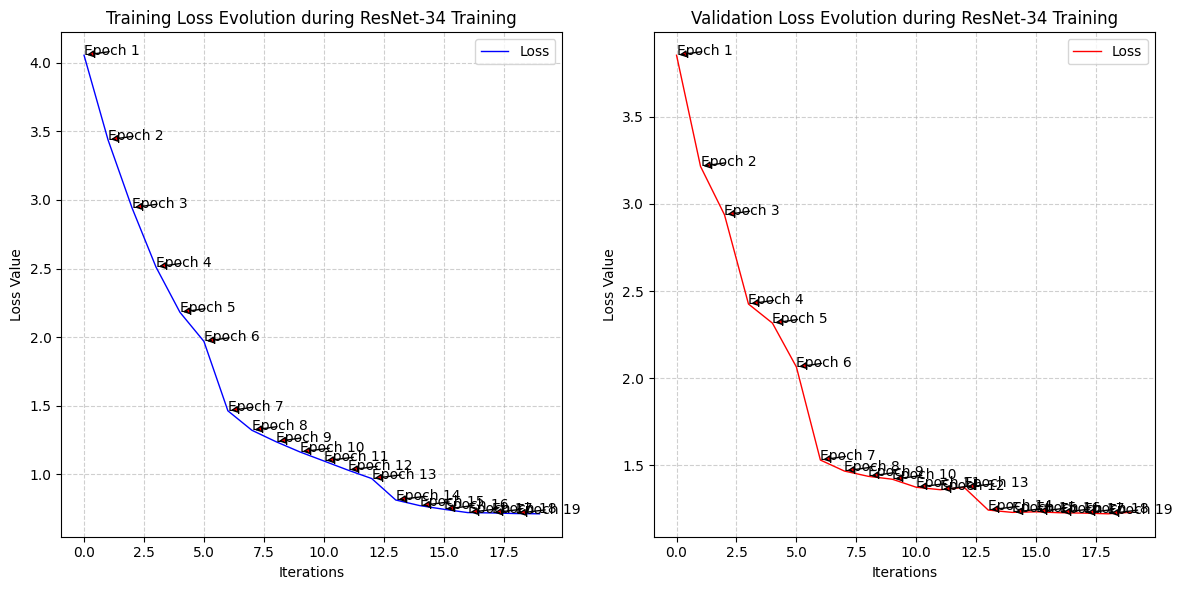

In [ ]:
import matplotlib.pyplot as plt

"""Mostly boilerplate/boring matplotlib code"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss_hist_r34, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during ResNet-34 Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 20): # 20 is the number of epochs we trained the "ResNet_34-from-scratch in Pytorch" model for
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss_hist_r34[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(val_loss_hist_r34, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during ResNet-34 Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 20):
    ax2.annotate(f'Epoch {i}', xy=(i-1, val_loss_hist_r34[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()

## We simply can't visualize 100 classes into a heatmap, so we choose the first 20 ones

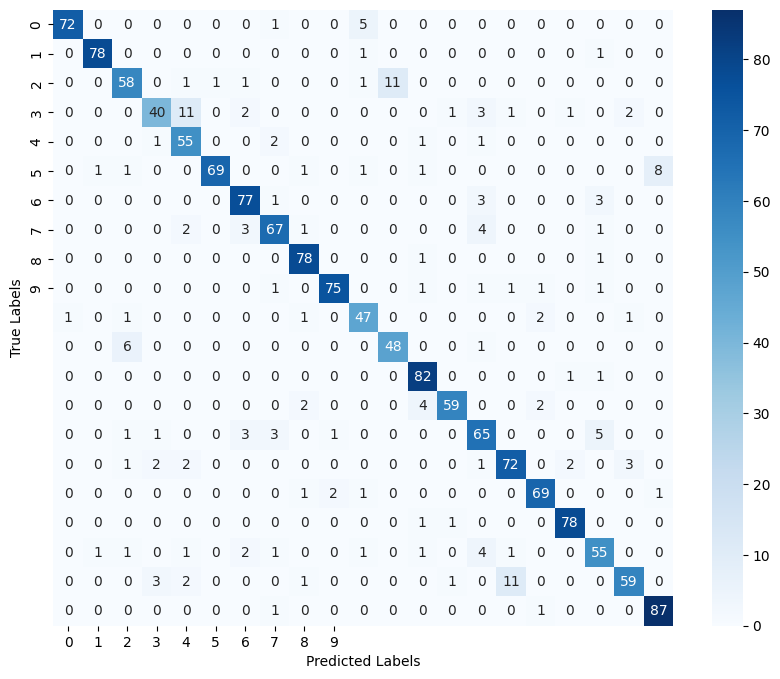

In [ ]:
max_limit = 20  # replace with a chosen limit
filtered_pairs = [
    (true, pred) for true, pred in zip(y_true_hist_r34, y_pred_hist_r34)
    if true <= max_limit and pred <= max_limit  # keeps pairs only if BOTH are under the limit
]

# sort the pairs (e.g., by the true labels)
filtered_pairs.sort(key=lambda pair: pair[0])

# unpack them back into separate lists
sorted_y_true_hist_r34 = [pair[0] for pair in filtered_pairs]
sorted_y_pred_hist_r34 = [pair[1] for pair in filtered_pairs]

confusion_mat = confusion_matrix(sorted_y_true_hist_r34, sorted_y_pred_hist_r34)

plt.figure(figsize=(10,8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

By analyzing the confusion matrix of the first Predicted/True labels chosen, we can see that the ResNet-34 model mistakenly predicted:
- Class 2 as being class 11 (11 times)
- Class 3 as being class 4 (11 times)
- Class 19 as being class 15 (11 times)
- Class 5 as being class 20 (8 times)

Lets observe these!

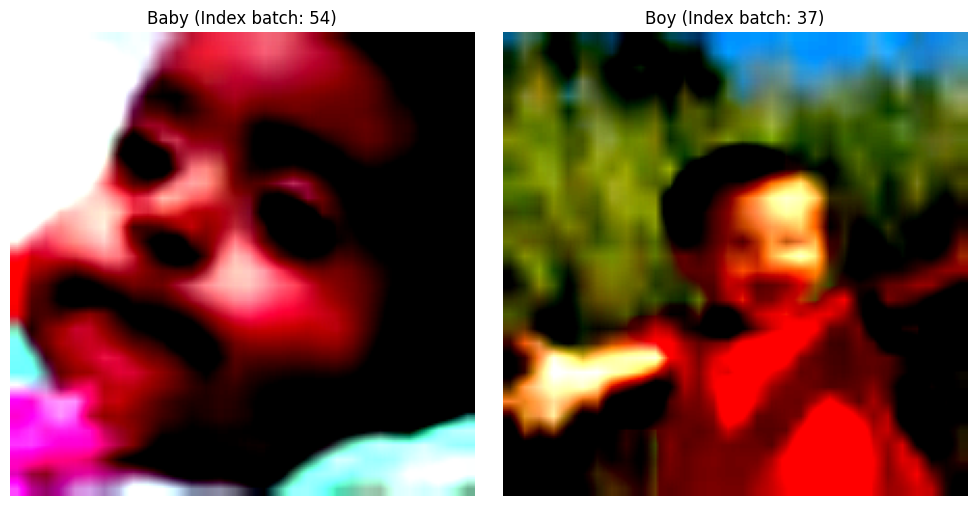

In [ ]:
"""Class 2 against class 11"""
loader_val_r34 = DataLoader(val_r34, batch_size=batch_size, shuffle=True)

image, label = next(iter(loader_val_r34))

rand_idx_baby = 2
rand_idx_boy = 11

idx_baby = torch.where(label == rand_idx_baby)[0]
idx_boy = torch.where(label == rand_idx_boy)[0]

# Verify if the current batch contains both classes
if len(idx_baby) > 0 and len(idx_boy) > 0:
  idx_baby = idx_baby[0] # First position where the label "baby" was found in the current batch
  idx_boy = idx_boy[0] # First position where the label "boy" was found in the current batch

  fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  ax1.imshow(image[idx_baby].permute(1, 2, 0))
  ax1.set_title(f"Baby (Index batch: {idx_baby})")
  ax1.axis('off')

  ax2.imshow(image[idx_boy].permute(1, 2, 0))
  ax2.set_title(f"Boy (Index batch: {idx_boy})")
  ax2.axis('off')

  plt.tight_layout()
  plt.show()

else:
  print("The random selected batch does not contain both desired classes")
  print("Try running it again!")

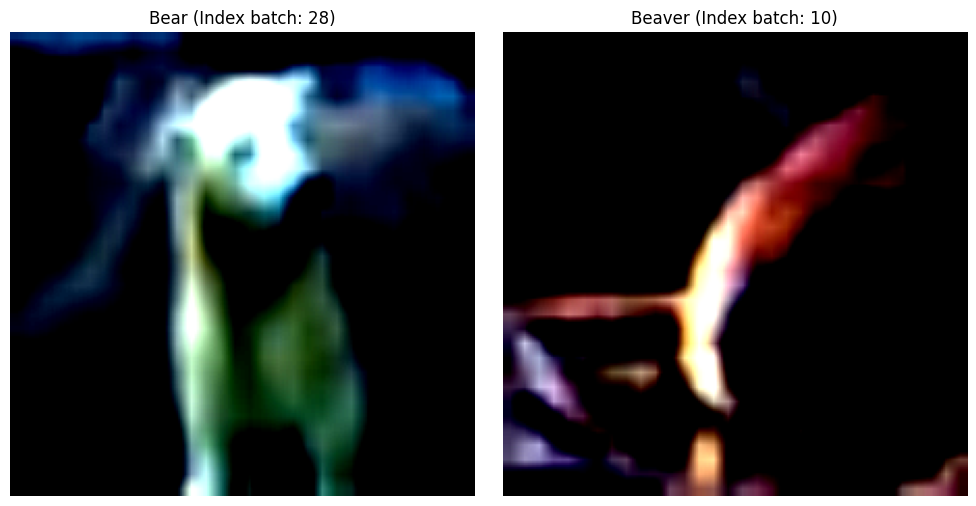

In [ ]:
"""Class 3 against class 4"""
loader_val_r34 = DataLoader(val_r34, batch_size=batch_size, shuffle=True)

image, label = next(iter(loader_val_r34))

rand_idx_bear= 3
rand_idx_beaver = 4

idx_bear = torch.where(label == rand_idx_bear)[0]
idx_beaver = torch.where(label == rand_idx_beaver)[0]

# Verify if the current batch contains both classes
if len(idx_bear) > 0 and len(idx_beaver) > 0:
  idx_bear = idx_bear[0] # First position where the label "bear" was found in the current batch
  idx_beaver = idx_beaver[0] # First position where the label "beaver" was found in the current batch

  fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  ax1.imshow(image[idx_bear].permute(1, 2, 0))
  ax1.set_title(f"Bear (Index batch: {idx_bear})")
  ax1.axis('off')

  ax2.imshow(image[idx_beaver].permute(1, 2, 0))
  ax2.set_title(f"Beaver (Index batch: {idx_beaver})")
  ax2.axis('off')

  plt.tight_layout()
  plt.show()

else:
  print("The random selected batch does not contain both desired classes")
  print("Try running it again!")

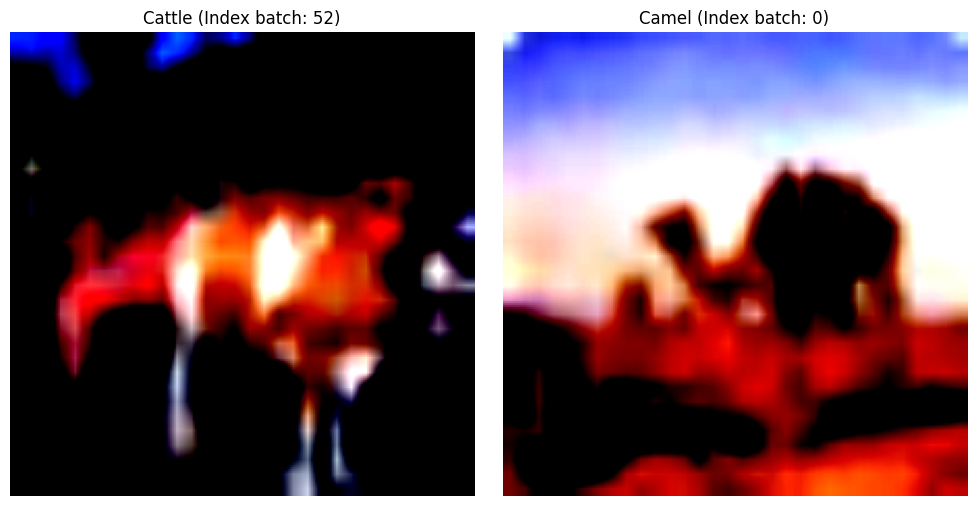

In [ ]:
"""Class 19 against class 15"""
loader_val_r34 = DataLoader(val_r34, batch_size=batch_size, shuffle=True)

image, label = next(iter(loader_val_r34))

rand_idx_cattle = 19
rand_idx_camel = 15

idx_cattle = torch.where(label == rand_idx_cattle)[0]
idx_camel = torch.where(label == rand_idx_camel)[0]

# Verify if the current batch contains both classes
if len(idx_cattle) > 0 and len(idx_camel) > 0:
  idx_cattle = idx_cattle[0] # First position where the label "cattle" was found in the current batch
  idx_camel = idx_camel[0] # First position where the label "camel" was found in the current batch

  fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  ax1.imshow(image[idx_cattle].permute(1, 2, 0))
  ax1.set_title(f"Cattle (Index batch: {idx_cattle})")
  ax1.axis('off')

  ax2.imshow(image[idx_camel].permute(1, 2, 0))
  ax2.set_title(f"Camel (Index batch: {idx_camel})")
  ax2.axis('off')

  plt.tight_layout()
  plt.show()

else:
  print("The random selected batch does not contain both desired classes")
  print("Try running it again!")

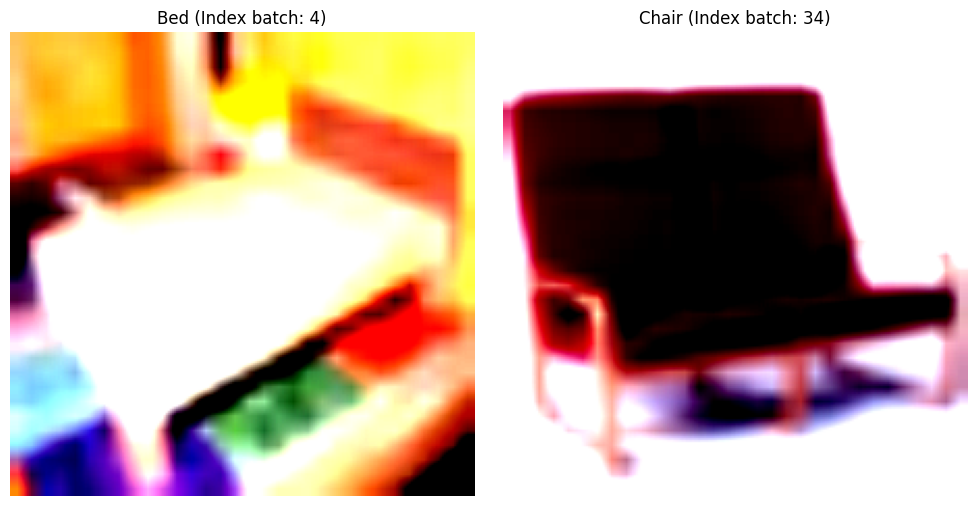

In [ ]:
"""Class 5 against class 20"""
loader_val_r34 = DataLoader(val_r34, batch_size=batch_size, shuffle=True)

image, label = next(iter(loader_val_r34))

rand_idx_bed = 5
rand_idx_chair = 20

idx_bed = torch.where(label == rand_idx_bed)[0]
idx_chair = torch.where(label == rand_idx_chair)[0]

# Verify if the current batch contains both classes
if len(idx_bed) > 0 and len(idx_chair) > 0:
  idx_bed = idx_bed[0] # First position where the label "bed" was found in the current batch
  idx_chair = idx_chair[0] # First position where the label "chair" was found in the current batch

  fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  ax1.imshow(image[idx_bed].permute(1, 2, 0))
  ax1.set_title(f"Bed (Index batch: {idx_bed})")
  ax1.axis('off')

  ax2.imshow(image[idx_chair].permute(1, 2, 0))
  ax2.set_title(f"Chair (Index batch: {idx_chair})")
  ax2.axis('off')

  plt.tight_layout()
  plt.show()

else:
  print("The random selected batch does not contain both desired classes")
  print("Try running it again!")

Now, **the ResNet_50-from-scratch model** wasn't trained on this notebook due to the lack of compute time the free Google Colab tier gives

I invite you to train it on CIFAR-100 and observe the predictions & the loss curve

In [ ]:
"""ResNet_50-from-scratch training class method"""
train_loss_hist_r50, val_loss_hist_r50, y_true_hist_r50, y_pred_hist_r50 = resnet50.fit(train_loader=loader_train_r50, val_loader=loader_val_r50, track=True, device=device, epochs=20)

In [ ]:
resnet50.save()

In [ ]:
files.download('ResNet50_model.pth')

In [ ]:
import matplotlib.pyplot as plt

"""Mostly boilerplate/boring matplotlib code"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss_hist_r50, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during ResNet-50 Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 20): # 20 is the number of epochs we trained the "ResNet_50-from-scratch in Pytorch" model for
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss_hist_r50[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(val_loss_hist_r50, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during ResNet-50 Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 20):
    ax2.annotate(f'Epoch {i}', xy=(i-1, val_loss_hist_r50[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()